# Hackathon IA - Analyse et Generation de Donnees

Ce notebook represente toute la partie "Donnees" de notre projet.
Nous allons generer des faux utilisateurs avec NumPy (en y injectant des erreurs volontaires),
nettoyer ces donnees sales avec Pandas, faire une analyse avec Matplotlib/Seaborn (Histogrammes, Cartes Thermiques),
et utiliser SciPy pour des statistiques.

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial import distance
import random
import os
import ast

# Pour pouvoir utiliser notre propre moteur de recommandation dans ce notebook
import sys
sys.path.append("../")
from src.models import UserProfile, ContentItem
from main import charger_catalogue, recommander_contenu

# On s'assure que le dossier data/ existe
if not os.path.exists("../data"):
    os.makedirs("../data")

# Design des graphiques
sns.set_theme(style="whitegrid")

## 1. Generation de Donnees Bruitees (NumPy)
Nous utilisons `numpy.random.normal` pour generer des ages realistes. 
Pour rendre l'exercice d'analyse de donnees "reel", nous allons volontairement injecter des erreurs (valeurs manquantes, ages negatifs, types de donnees incorrects).

Nous ajoutons egalement une **Heure d'activite** pour chaque action afin de pouvoir construire une Carte Thermique plus tard.

In [77]:
np.random.seed(42) 
ALL_INTERESTS = ["technology", "music", "fitness", "health", "ai", "business", "science"]
ALL_ACTIVITIES = ["watched ai talk", "listened to rock", "bought headphones", "completed workout"]

# NumPy genere une distribution normale d'ages (Moyenne 35, Ecart-type 12)
ages_generes = np.random.normal(loc=35, scale=12, size=50)

utilisateurs_bruts = []
journal_activites = []  # Pour stocker le detail des activites avec l'heure

for i in range(50):
    # Injection d'erreurs dans l'age pour rendre le nettoyage necessaire
    chance = random.random()
    if chance < 0.10:
        age = None  # Valeur manquante (NaN)
    elif chance < 0.15:
        age = "inconnu"  # Erreur de type
    elif chance < 0.20:
        age = -5  # Age impossible
    else:
        age = int(ages_generes[i])
        
    nb_interets = random.randint(1, 3)
    interets = random.sample(ALL_INTERESTS, nb_interets)
    
    nb_activites = random.randint(1, 3)
    
    activites_user = []
    for _ in range(nb_activites):
        act = random.choice(ALL_ACTIVITIES)
        heure = int(np.random.normal(loc=18, scale=4))  # Heure moyenne d'activite: 18h
        heure = max(0, min(23, heure))  # On s'assure que c'est entre 0 et 23h
        activites_user.append(act)
        
        # On sauvegarde le detail pour la Heatmap plus tard
        journal_activites.append({"user_id": f"u{i+1}", "Activity": act, "Hour": heure})
    
    user = {
        "user_id": f"u{i+1}",
        "Name": f"Utilisateur {i+1}",
        "Age": age,
        "Interests": interets,
        "Activity Logs": activites_user
    }
    utilisateurs_bruts.append(user)

# Sauvegarde du fichier "sale" dans un CSV
df_sale = pd.DataFrame(utilisateurs_bruts)
print(df_sale.head())

df_sale.to_csv("../data/users_raw.csv", index=False)
print("\nFichier 'users_raw.csv' genere avec succes (contenant des erreurs).")

# On garde le detail des activites dans un DataFrame pour la Heatmap
df_activites = pd.DataFrame(journal_activites)
df_activites.to_csv("../data/activities_raw.csv", index=False)
print("\nFichier 'activities_raw.csv' genere avec succes")
df_activites.head(25)

  user_id           Name Age                   Interests  \
0      u1  Utilisateur 1  -5  [ai, technology, business]   
1      u2  Utilisateur 2  33       [science, technology]   
2      u3  Utilisateur 3  42                  [business]   
3      u4  Utilisateur 4  53                [technology]   
4      u5  Utilisateur 5  -5            [ai, technology]   

                                       Activity Logs  
0                                 [listened to rock]  
1                                [completed workout]  
2  [listened to rock, watched ai talk, completed ...  
3                                  [watched ai talk]  
4  [listened to rock, bought headphones, complete...  

Fichier 'users_raw.csv' genere avec succes (contenant des erreurs).

Fichier 'activities_raw.csv' genere avec succes


,user_id,Activity,Hour
0,u1,listened to rock,19
1,u2,completed workout,16
2,u3,listened to rock,15
3,u3,watched ai talk,20
4,u3,completed workout,22
5,u4,watched ai talk,21
6,u5,listened to rock,14
7,u5,bought headphones,16
8,u5,completed workout,19
9,u6,completed workout,21


## 2. Exploration et Nettoyage des Donnees (Pandas)

In [78]:
df = pd.read_csv("../data/users_raw.csv")

In [79]:
print(f"Shape du dataframe: {df.shape}")
print(f"\nTypes de données:\n{df.dtypes}")
print(f"\nInformations générales:\n")
print(df.info())
print("\n")



Shape du dataframe: (50, 5)

Types de données:
user_id          str
Name             str
Age              str
Interests        str
Activity Logs    str
dtype: object

Informations générales:

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        50 non-null     str  
 1   Name           50 non-null     str  
 2   Age            47 non-null     str  
 3   Interests      50 non-null     str  
 4   Activity Logs  50 non-null     str  
dtypes: str(5)
memory usage: 2.1 KB
None




In [80]:
# identification des valeurs manquantes
print(f"Valeurs manquantes par colonne:\n{df.isnull().sum()}\n")
print(f"Pourcentage de valeurs manquantes:\n{df.isnull().sum() / len(df) * 100}\n")
print("\n")

Valeurs manquantes par colonne:
user_id          0
Name             0
Age              3
Interests        0
Activity Logs    0
dtype: int64

Pourcentage de valeurs manquantes:
user_id          0.0
Name             0.0
Age              6.0
Interests        0.0
Activity Logs    0.0
dtype: float64





In [81]:
# 2. Nettoyage de la colonne Age
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df_clean = df.dropna(subset=['Age']).copy()
df_clean = df_clean[(df_clean['Age'] >= 1) & (df_clean['Age'] <= 120)]
df_clean['Age'] = df_clean['Age'].astype(int)


In [82]:
# 3. Sauvegarde du fichier "propre"
df.to_csv("../data/users_clean.csv", index=False)
print(f"\nNettoyage termine ! Il reste {len(df)} utilisateurs valides sur les 50.")


Nettoyage termine ! Il reste 50 utilisateurs valides sur les 50.


In [83]:
df_clean.head(50)

,user_id,Name,Age,Interests,Activity Logs
1,u2,Utilisateur 2,33,"['science', 'technology']",['completed workout']
2,u3,Utilisateur 3,42,['business'],"['listened to rock', 'watched ai talk', 'compl..."
3,u4,Utilisateur 4,53,['technology'],['watched ai talk']
5,u6,Utilisateur 6,32,"['health', 'science', 'fitness']",['completed workout']
6,u7,Utilisateur 7,53,"['technology', 'business', 'ai']",['watched ai talk']
7,u8,Utilisateur 8,44,['fitness'],"['watched ai talk', 'bought headphones', 'boug..."
8,u9,Utilisateur 9,29,"['science', 'health']","['completed workout', 'watched ai talk']"
9,u10,Utilisateur 10,41,"['music', 'science', 'health']","['bought headphones', 'listened to rock', 'bou..."
10,u11,Utilisateur 11,29,"['business', 'fitness', 'technology']","['listened to rock', 'watched ai talk', 'watch..."
12,u13,Utilisateur 13,37,"['business', 'fitness', 'music']","['listened to rock', 'listened to rock']"


In [84]:
df_clean.describe()

,Age
count,40.000000
mean,33.250000
std,11.362895
min,11.000000
25%,27.000000
50%,33.500000
75%,39.500000
max,57.000000


In [85]:
print (f"L'échantillon contient {len(df_clean)} personnes, avec un âge moyen d'environ {df_clean['Age'].mean():.0f} ans. La majorité des individus sont regroupés entre {df_clean['Age'].min()} et {df_clean['Age'].max()} ans, mais quelques valeurs plus jeunes (jusqu'à {df_clean['Age'].quantile(0.25):.0f} ans) et plus âgées (jusqu'à {df_clean['Age'].quantile(0.75):.0f} ans) élargissent la dispersion globale. La proximité entre la moyenne et la médiane suggère une distribution globalement assez équilibrée, sans forte influence de valeurs extrêmes.")

L'échantillon contient 40 personnes, avec un âge moyen d'environ 33 ans. La majorité des individus sont regroupés entre 11 et 57 ans, mais quelques valeurs plus jeunes (jusqu'à 27 ans) et plus âgées (jusqu'à 40 ans) élargissent la dispersion globale. La proximité entre la moyenne et la médiane suggère une distribution globalement assez équilibrée, sans forte influence de valeurs extrêmes.


## 3
. Visualisation des Donnees (Matplotlib & Seaborn)

Conformement aux consignes, nous devons afficher la repartition des ages/interets, mais surtout **une carte thermique de l'intensite d'activite par heure**.

In [86]:
# Extraction propre des listes depuis le CSV
df_clean['Interests'] = df_clean['Interests'].apply(ast.literal_eval)
df_clean['Activity Logs'] = df_clean['Activity Logs'].apply(ast.literal_eval)

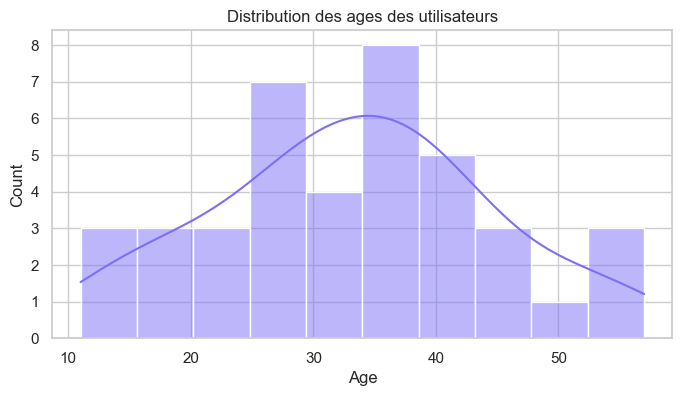

In [87]:
# 3.1 Distribution des Ages
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Age'], bins=10, kde=True, color="#7C6FF7")
plt.title("Distribution des ages des utilisateurs")
plt.xlabel("Age")
plt.show()

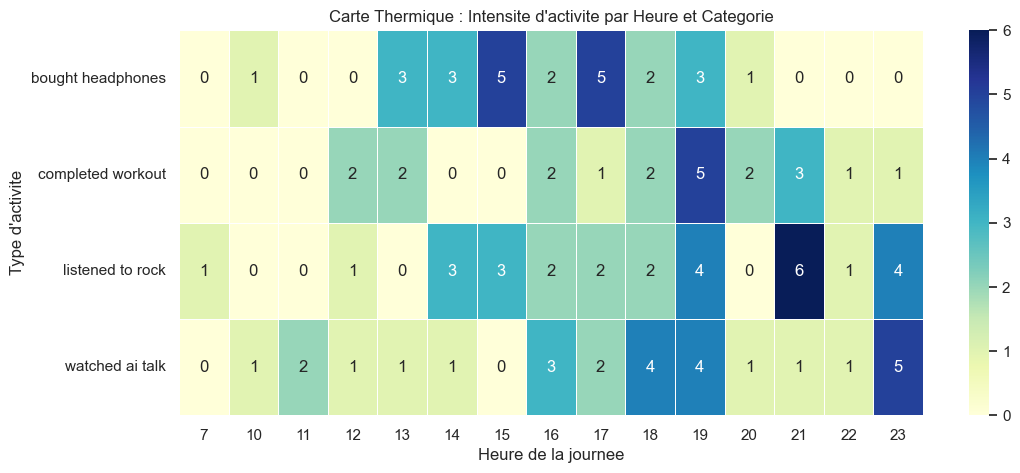

In [88]:
# 3.2 Carte Thermique (Heatmap) des activites par heure
# On prepare une matrice : Lignes = Activites, Colonnes = Heures
matrice_activite = pd.crosstab(df_activites['Activity'], df_activites['Hour'])

plt.figure(figsize=(12, 5))
sns.heatmap(matrice_activite, cmap="YlGnBu", annot=True, cbar=True, linewidths=.5)
plt.title("Carte Thermique : Intensite d'activite par Heure et Categorie")
plt.xlabel("Heure de la journee")
plt.ylabel("Type d'activite")
plt.show()

## 4. Graphique des Recommandations (Integration du Moteur)

Consigne : *"Creez des graphiques a barres des categories les plus recommandees par segment d'utilisateurs."*

Nous allons utiliser notre logique `recommander_contenu` issue de `main.py` et `models.py` pour generer des recommandations pour tout le monde, et tracer le graphique.

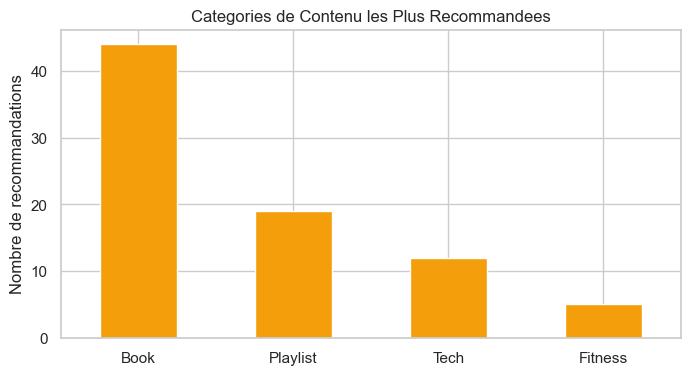

In [89]:
catalogue = charger_catalogue()
categories_recommandees = []

for index, row in df_clean.iterrows():
    # Creation de l'objet utilisateur (POO)
    user = UserProfile(
        user_id=row['user_id'], 
        name=row['Name'], 
        age=row['Age'], 
        interests=row['Interests'],
        activity_log=row['Activity Logs']
    )
    
    # Obtenir les 2 meilleures recommandations
    recos = recommander_contenu(user, catalogue, top_n=2)
    for r in recos:
        categories_recommandees.append(r.category)

# 4.1 Bar Chart des Categories les plus recommandees
series_recos = pd.Series(categories_recommandees)
plt.figure(figsize=(8, 4))
series_recos.value_counts().plot(kind='bar', color="#F59E0B")
plt.title("Categories de Contenu les Plus Recommandees")
plt.ylabel("Nombre de recommandations")
plt.xticks(rotation=0)
plt.show()

## 5. Analyse Statistique avec SciPy

Consignes : Test du Chi-Carre et Similarite Cosinus.

In [ ]:
tous_les_interets = [i for liste in df_clean['Interests'] for i in liste]
compte_interets = pd.Series(tous_les_interets).value_counts()

frequences_observees = compte_interets.values
moyenne = np.mean(frequences_observees)
frequences_attendues = [moyenne] * len(frequences_observees)

# Test du Chi-Carre
stat_chi2, p_value = stats.chisquare(frequences_observees, frequences_attendues)

print(f"Test du Chi-Carre : {stat_chi2:.2f} (P-Value: {p_value:.4f})")
if p_value < 0.05:
    print("Difference significative ! La repartition des interets n'est pas liee au hasard.")
else:
    print("La repartition des interets est plutot uniforme.")


# Similarite Cosinus entre l'utilisateur 1 et 2
def profil_vers_vecteur(interets_user):
    vecteur = np.zeros(len(ALL_INTERESTS))
    for i, interet in enumerate(ALL_INTERESTS):
        if interet in interets_user:
            vecteur[i] = 1.0
    return vecteur

vec1 = profil_vers_vecteur(df_clean.iloc[0]['Interests'])
vec2 = profil_vers_vecteur(df_clean.iloc[1]['Interests'])

ressemblance = (1 - distance.cosine(vec1, vec2)) * 100
print(f"\nLe calcul SciPy montre que l'Utilisateur 1 et 2 ont {ressemblance:.1f}% de similarite.")

Test du Chi-Carre : 1.75 (P-Value: 0.9414)
La repartition des interets est plutot uniforme.

Le calcul SciPy montre que l'Utilisateur 1 et 2 ont 0.0% de similarite.
